# 1. IMPORTING NECESSARY LIBRARIES

In [31]:
# Importing data tools
import pandas as pd

# Importing data visual tools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importing Scipy
import scipy.stats as stats
from scipy.stats import skew, kurtosis, shapiro, normaltest, kstest, norm

# Importing Gradient Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

## 1.1. Initializing constant values

In [32]:
n_split = 5
random_state = 28

## 1.2 Initializing Dataset

In [33]:
df = pd.read_csv("creditcard.csv")

## 1.3 SUMMARY STATISTICS

In [34]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
df.shape

(284807, 31)

In [9]:
df.duplicated().sum()

np.int64(1081)

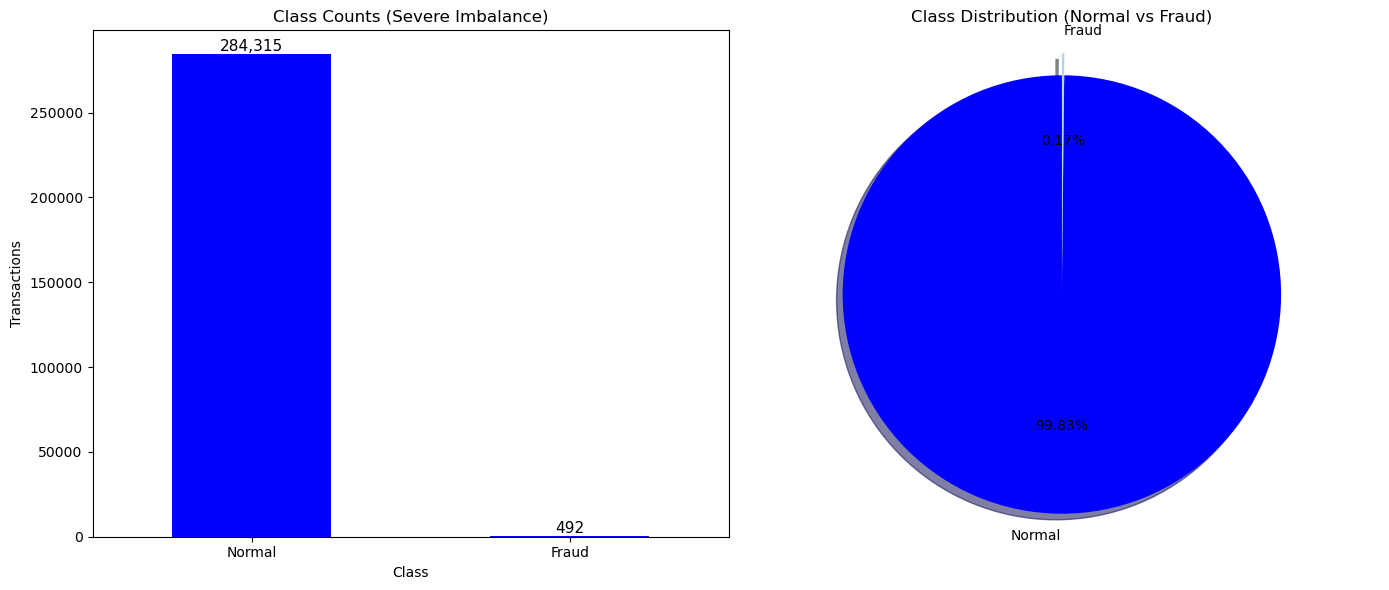

In [10]:
# Counts
counts = df['Class'].value_counts().rename({0:'Normal', 1:'Fraud'})

# Create 1 row, 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# --- Bar Plot ---
counts.plot(kind='bar', ax=ax[0], color='blue')  # bar color
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=11)

ax[0].set_title('Class Counts (Severe Imbalance)')
ax[0].set_ylabel('Transactions')
ax[0].set_xlabel('Class')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# --- Pie Chart ---
ax[1].pie(counts.values,
          labels=counts.index,
          autopct='%1.2f%%',
          startangle=90,
          explode=[0,0.1],
          shadow=True,
          colors=['blue','lightblue'])  # pie colors

ax[1].set_title('Class Distribution (Normal vs Fraud)')
ax[1].axis('equal')

plt.tight_layout()
plt.show()

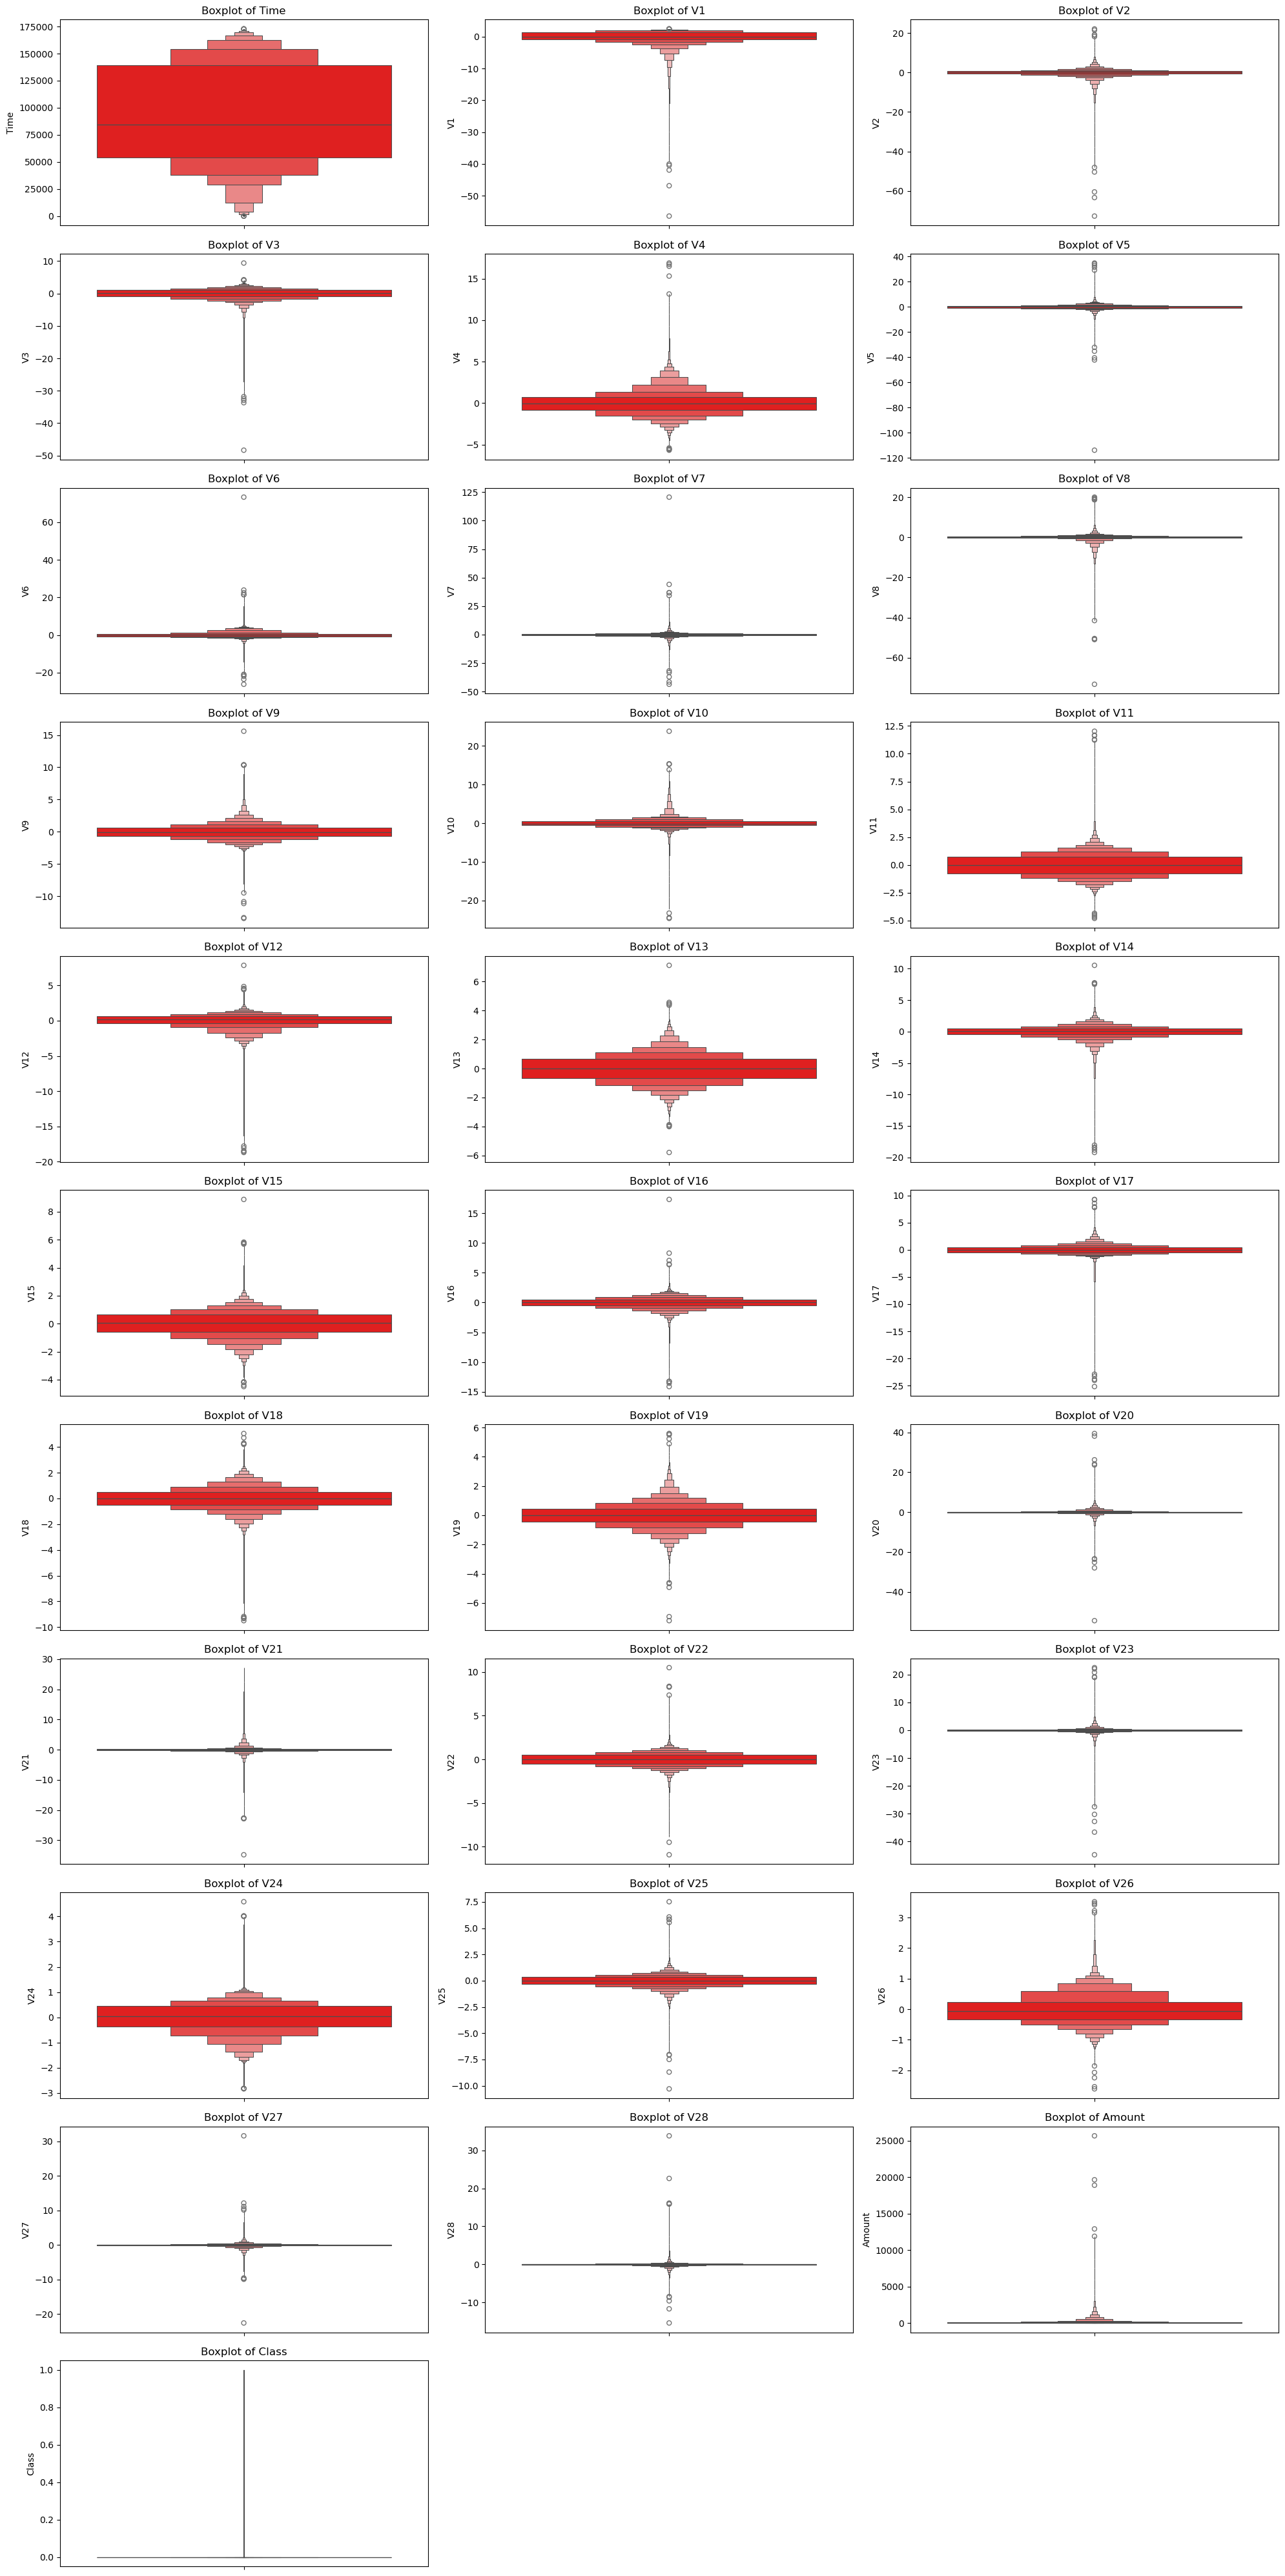

In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxenplot(y=df[col], color="red")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

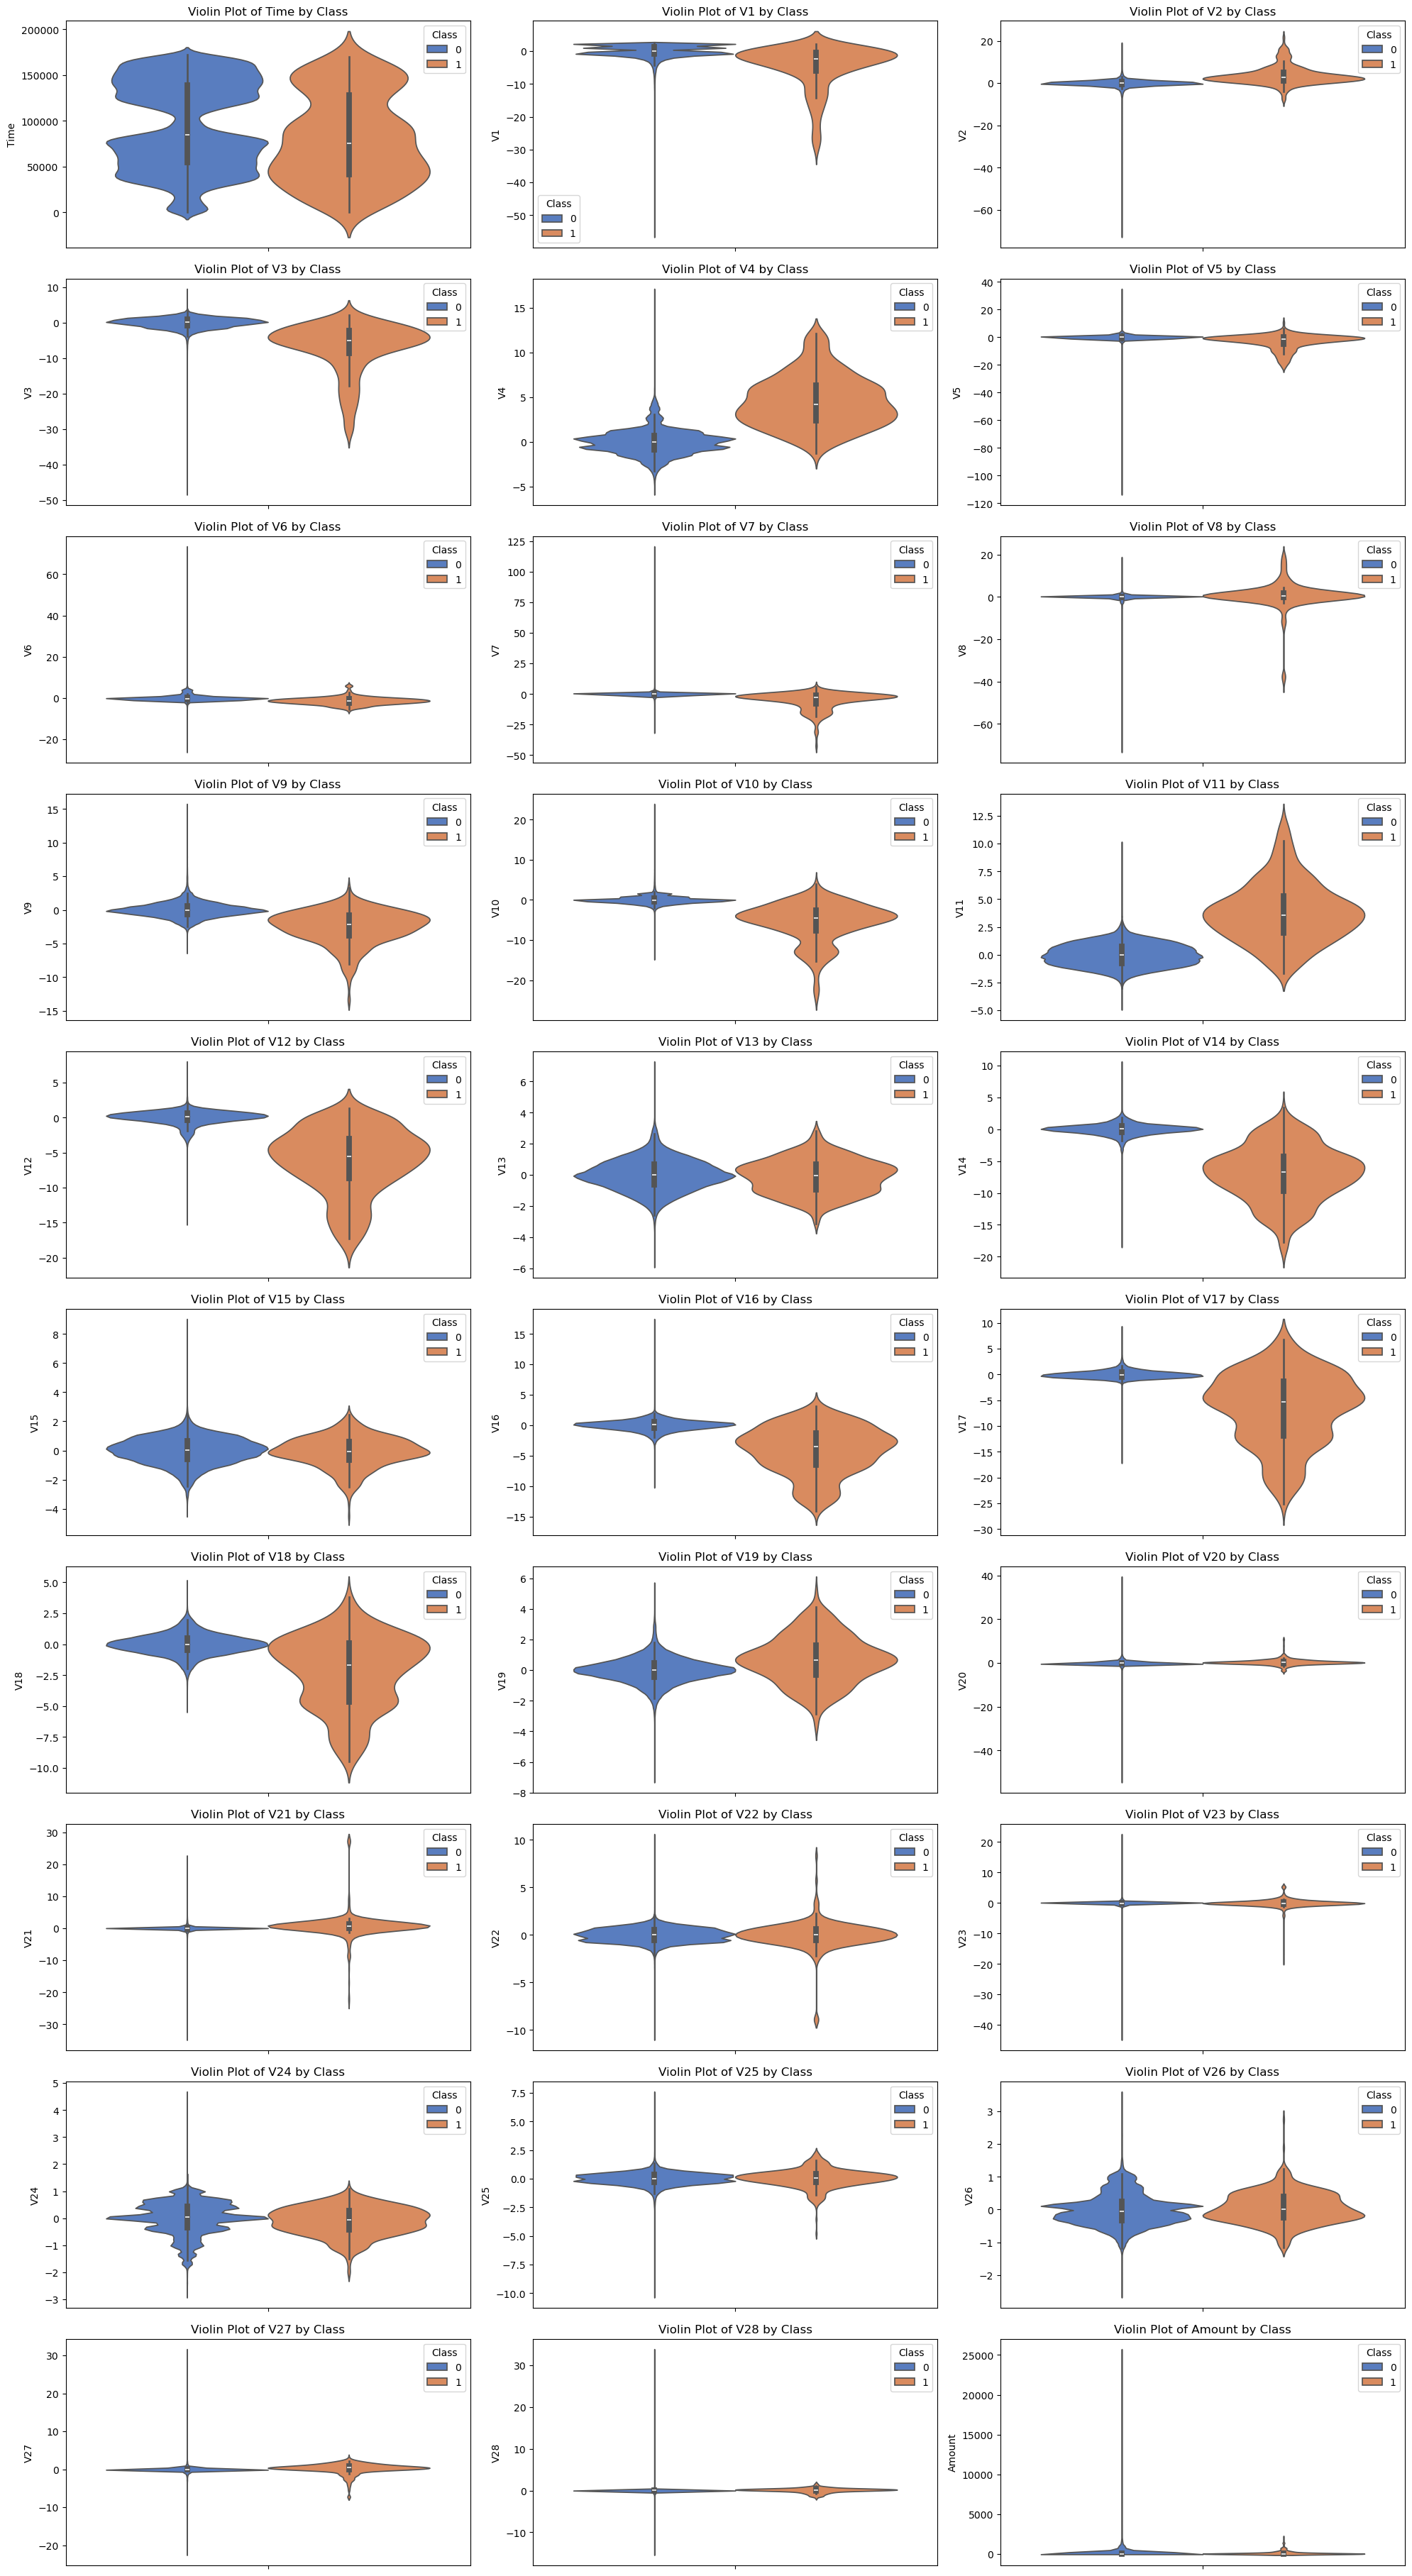

In [13]:
plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    if col != "Class":
        plt.subplot(len(numeric_cols)//3 + 1, 3, i)
        sns.violinplot(data=df, hue="Class", y=col, palette="muted")
        plt.title(f"Violin Plot of {col} by Class")

plt.tight_layout()
plt.show()

In [14]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [15]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

# 2. CREATING BOOTSTRAPING FUNCTION

In [16]:
# Bootstrap resampling
def bootstrap_comparison(data, n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50):
    """
    Compare original distribution vs bootstrap distribution of the mean.
    
    Parameters
    ----------
    data : array-like (Series, ndarray)
        Input data (e.g., df["Time"])
    n_boot : int, default=1000
        Number of bootstrap resamples
    random_state : int, default=42
        Seed for reproducibility
    bins_orig : int, default=100
        Number of bins for original distribution histogram
    bins_boot : int, default=50
        Number of bins for bootstrap distribution histogram
    """
    
    rng = np.random.default_rng(seed=random_state)
    data = np.asarray(data)

    # Bootstrap resampling
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means[i] = sample.mean()

    # --- Summary statistics ---
    # Original distribution
    orig_mean = data.mean()
    orig_std = data.std()
    orig_median = np.median(data)
    orig_mode = stats.mode(data, keepdims=True)[0][0]
    orig_ci_lower, orig_ci_upper = np.percentile(data, [2.5, 97.5])

    # Bootstrap distribution
    boot_mean = boot_means.mean()
    boot_std = boot_means.std()
    boot_median = np.median(boot_means)
    boot_mode = stats.mode(boot_means, keepdims=True)[0][0]
    boot_ci_lower, boot_ci_upper = np.percentile(boot_means, [2.5, 97.5])

    # --- Plot side by side ---
    fig, ax = plt.subplots(1, 2, figsize=(14,6))

    # Original distribution
    sns.histplot(data, bins=bins_orig, kde=True, color="green", ax=ax[0])
    ax[0].set_title("Distribution of Original Data")
    ax[0].set_xlabel("Value")
    ax[0].set_ylabel("Frequency")
    ax[0].axvline(orig_mean, color="red", linestyle="--", label=f"Mean = {orig_mean:.2f}")
    ax[0].axvline(orig_median, color="green", linestyle="--", label=f"Median = {orig_median:.2f}")
    ax[0].axvline(orig_mode, color="purple", linestyle="--", label=f"Mode = {orig_mode:.2f}")
    ax[0].axvline(orig_ci_lower, color="orange", linestyle=":", label=f"95% CI Lower = {orig_ci_lower:.2f}")
    ax[0].axvline(orig_ci_upper, color="orange", linestyle=":", label=f"95% CI Upper = {orig_ci_upper:.2f}")
    ax[0].legend()

    # Bootstrap distribution
    sns.histplot(boot_means, bins=bins_boot, kde=True, color="blue", ax=ax[1])
    ax[1].set_title("Bootstrap Distribution of Mean")
    ax[1].set_xlabel("Mean Value")
    ax[1].set_ylabel("Frequency")
    ax[1].axvline(boot_mean, color="red", linestyle="--", label=f"Mean = {boot_mean:.2f}")
    ax[1].axvline(boot_median, color="green", linestyle="--", label=f"Median = {boot_median:.2f}")
    ax[1].axvline(boot_mode, color="purple", linestyle="--", label=f"Mode = {boot_mode:.2f}")
    ax[1].axvline(boot_ci_lower, color="orange", linestyle=":", label=f"95% CI Lower = {boot_ci_lower:.2f}")
    ax[1].axvline(boot_ci_upper, color="orange", linestyle=":", label=f"95% CI Upper = {boot_ci_upper:.2f}")
    ax[1].legend()

    # Transformed distribution
    plt.tight_layout()
    plt.show()

# 3. EXPLORING TIME DISTRIBUTION

============================================================ Time Distribution ============================================================


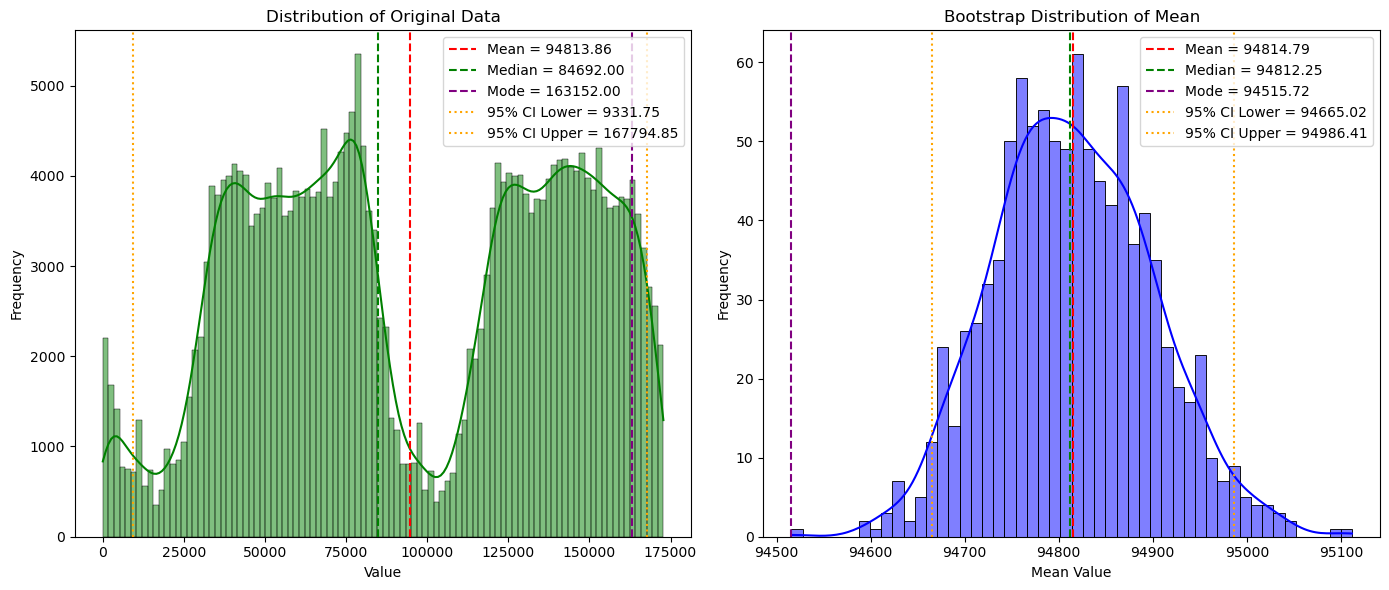

In [17]:
print("="*60, "Time Distribution","="*60)
bootstrap_comparison(df["Time"], n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50)

In [18]:
def skewness(col):
    # If it's a pandas Series, use .skew(); if ndarray, use scipy
    if hasattr(col, "skew"):  
        skew_val = col.skew()
    else:
        skew_val = skew(col)

    if skew_val > 1:
        interpretation = "Highly right skewed"
    elif 0.5 < skew_val <= 1:
        interpretation = "Moderately right skewed"
    elif -0.5 <= skew_val <= 0.5:
        interpretation = "Approximately symmetric"
    elif -1 <= skew_val < -0.5:
        interpretation = "Moderately left skewed"
    else:
        interpretation = "Highly left skewed"
    return f"Skewness: {skew_val:.4f} → {interpretation}"

def kurtosis_val(col):
    # pandas Series has .kurt(); ndarray needs scipy.kurtosis
    if hasattr(col, "kurt"):
        kurt_val = col.kurt()
    else:
        kurt_val = kurtosis(col, fisher=False)  # Pearson definition (normal=3)

    if kurt_val > 3:
        interpretation = "Leptokurtic (heavy tails, more outliers)"
    elif kurt_val < 3:
        interpretation = "Platykurtic (light tails, fewer outliers)"
    else:
        interpretation = "Mesokurtic (close to normal)"
    return f"Kurtosis: {kurt_val:.4f} → {interpretation}"

def d_agostino_normality(col):
    # Shapiro-Wilk test
    stat, p = normaltest(col)
    interpretation = "Data looks normally distributed (fail to reject H0)" if p > 0.05 else "Data is not normally distributed (reject H0)"
    return f"D'Agostino-Pearson p-value: {p:.4f} → {interpretation}"

def ks_normality(col):
    # Shapiro-Wilk test
    stat, p = normaltest(col)
    interpretation = "Data looks normally distributed (fail to reject H0)" if p > 0.05 else "Data is not normally distributed (reject H0)"
    return f"Kolmogorov-Smirnov p-value: {p:.4f} → {interpretation}"

In [19]:
df_time = df["Time"].values
original_col = df_time
rng = np.random.default_rng(seed=random_state)

boot_means = []
for i in range(1000):
    sample = rng.choice(data, size=len(data), replace=True)
    boot_means.append(sample.mean())

bootstrap_col = boot_means

In [20]:
print(kurtosis_val(original_col))
print(kurtosis_val(bootstrap_col))

Kurtosis: 1.7065 → Platykurtic (light tails, fewer outliers)
Kurtosis: 2.9742 → Platykurtic (light tails, fewer outliers)


In [21]:
print(d_agostino_normality(original_col))
print(d_agostino_normality(bootstrap_col))

D'Agostino-Pearson p-value: 0.0000 → Data is not normally distributed (reject H0)
D'Agostino-Pearson p-value: 0.1610 → Data looks normally distributed (fail to reject H0)


In [22]:
print(ks_normality(original_col))
print(ks_normality(bootstrap_col))

Kolmogorov-Smirnov p-value: 0.0000 → Data is not normally distributed (reject H0)
Kolmogorov-Smirnov p-value: 0.1610 → Data looks normally distributed (fail to reject H0)


# 4. EXPLORING AMOUNT DISTRIBUTION

============================================================ Amount Distribution ============================================================


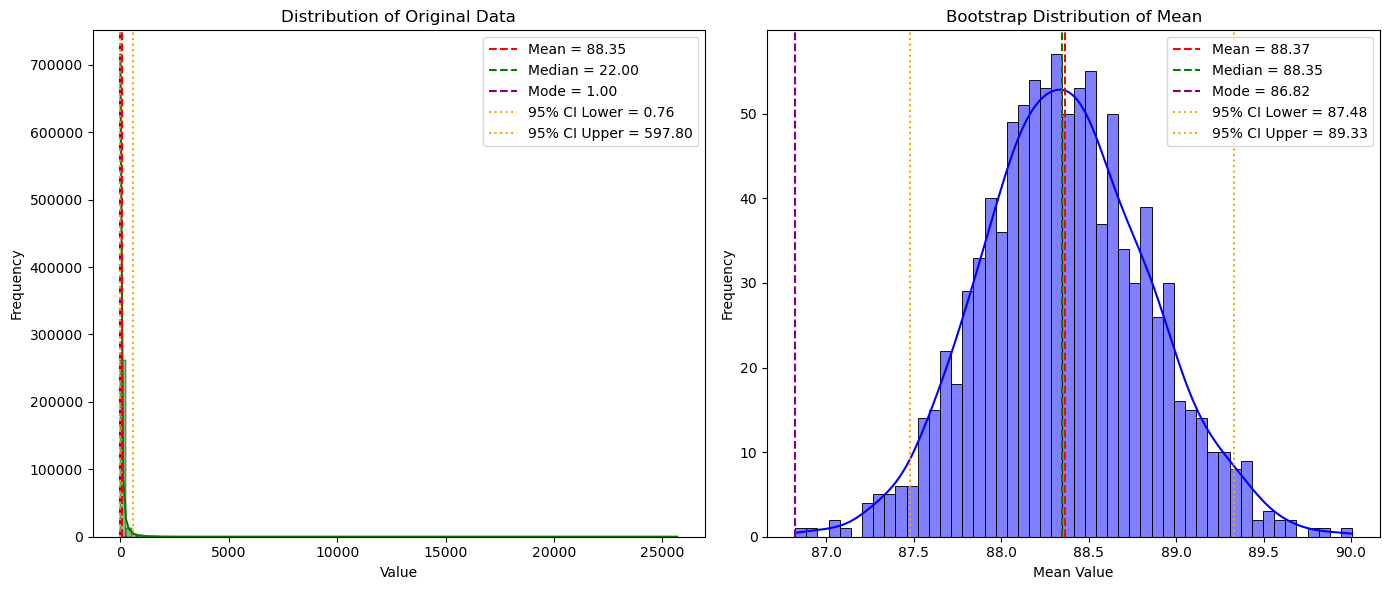

In [23]:
print("="*60, "Amount Distribution","="*60)
bootstrap_comparison(df["Amount"], n_boot=1000, random_state=random_state, bins_orig=100, bins_boot=50)

In [24]:
df_amount = df["Amount"]

# Bootstrap resampling
rng = np.random.default_rng(seed=random_state)
n_boot = 1000
boot_means = np.empty(n_boot)

for i in range(n_boot):
    sample = rng.choice(data, size=len(data), replace=True)
    boot_means[i] = sample.mean()

# Now compare original vs bootstrap
original_col = df_amount
bootstrap_col = boot_means

print(skewness(original_col))
print(skewness(bootstrap_col))
print(kurtosis_val(original_col))
print(kurtosis_val(bootstrap_col))
print(d_agostino_normality(original_col))
print(d_agostino_normality(bootstrap_col))
print(ks_normality(original_col))
print(ks_normality(bootstrap_col))

Skewness: 16.9777 → Highly right skewed
Skewness: 0.1092 → Approximately symmetric
Kurtosis: 845.0926 → Leptokurtic (heavy tails, more outliers)
Kurtosis: 3.0642 → Leptokurtic (heavy tails, more outliers)
D'Agostino-Pearson p-value: 0.0000 → Data is not normally distributed (reject H0)
D'Agostino-Pearson p-value: 0.3206 → Data looks normally distributed (fail to reject H0)
Kolmogorov-Smirnov p-value: 0.0000 → Data is not normally distributed (reject H0)
Kolmogorov-Smirnov p-value: 0.3206 → Data looks normally distributed (fail to reject H0)


# 5. SCALING TIME AND AMOUNT

In [35]:
"""
Since our dataset has already been transformed using PCA (except for the amount and time columns), we need to apply 
the appropriate transformations to those columns before training. 
If we train the classification model directly without these transformations, it will likely result in low scores.
"""

# From extracted columns
df_amount = df["Amount"]
df_time = df["Time"]

std_scaler = StandardScaler()
rob_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()

# For amount column
df_std_amount = std_scaler.fit_transform(df_amount.values.reshape(-1,1))
df_rob_amount = rob_scaler.fit_transform(df_amount.values.reshape(-1,1))
df_minmax_amount = minmax_scaler.fit_transform(df_amount.values.reshape(-1,1))

# For time column
df_std_time = std_scaler.fit_transform(df_time.values.reshape(-1,1))
df_rob_time = rob_scaler.fit_transform(df_time.values.reshape(-1,1))
df_minmax_time = minmax_scaler.fit_transform(df_time.values.reshape(-1,1))

# 6. VISUALIZING TRANSFORMATION

Text(0, 0.5, 'Frequency')

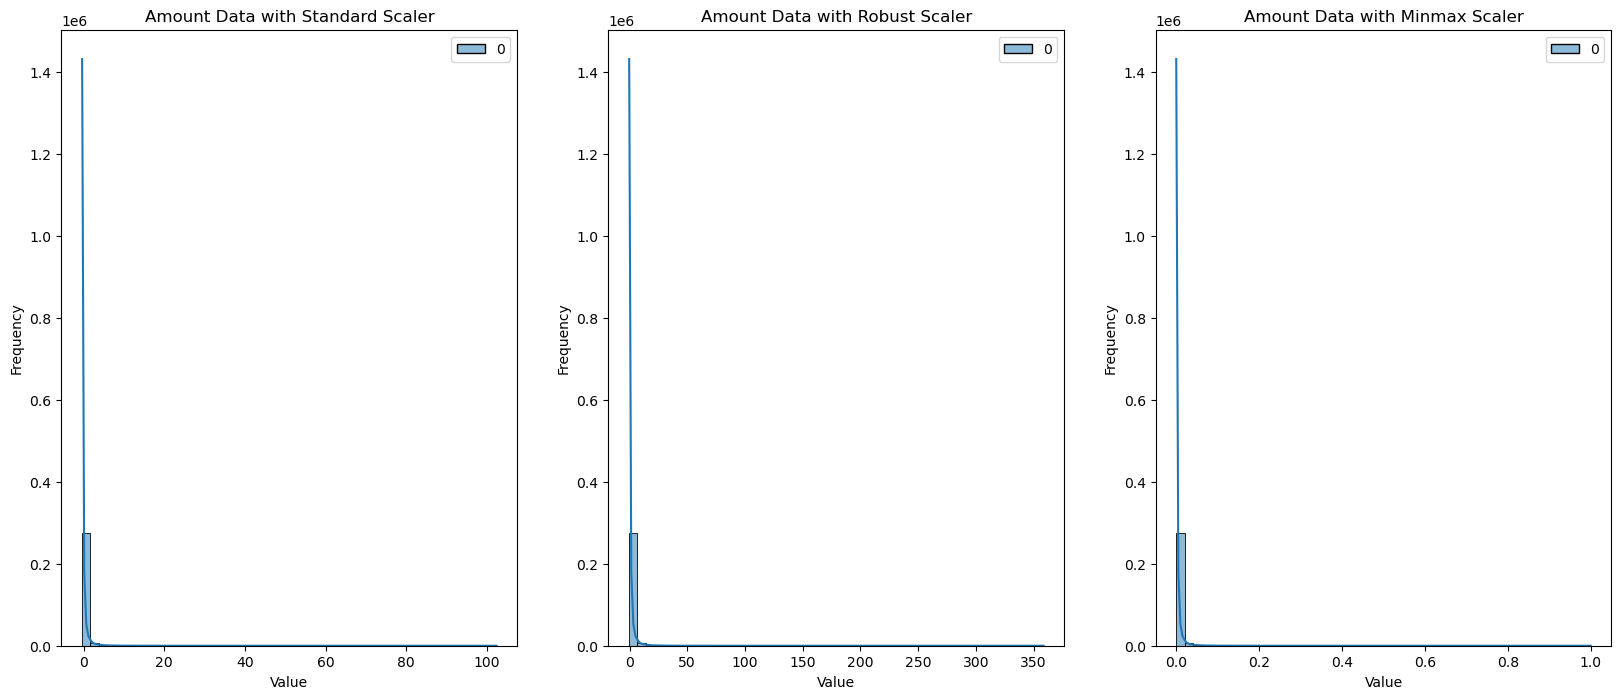

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(20,8))

# Original distribution
sns.histplot(df_std_amount, bins=50, kde=True, color="green", ax=ax[0])
ax[0].set_title("Amount Data with Standard Scaler")
ax[0].set_xlabel("Value")
ax[0].set_ylabel("Frequency")

sns.histplot(df_rob_amount, bins=50, kde=True, color="blue", ax=ax[1])
ax[1].set_title("Amount Data with Robust Scaler")
ax[1].set_xlabel("Value")
ax[1].set_ylabel("Frequency")

sns.histplot(df_minmax_amount, bins=50, kde=True, color="blue", ax=ax[2])
ax[2].set_title("Amount Data with Minmax Scaler")
ax[2].set_xlabel("Value")
ax[2].set_ylabel("Frequency")

Text(0, 0.5, 'Frequency')

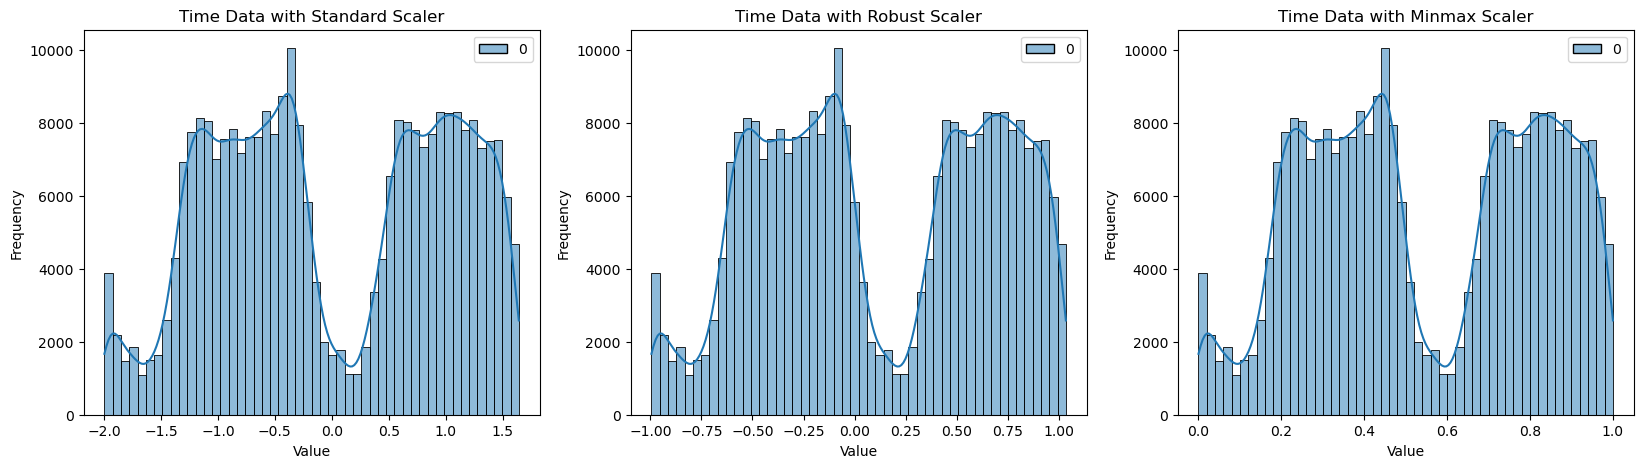

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))

# Original distribution
sns.histplot(df_std_time, bins=50, kde=True, color="green", ax=ax[0])
ax[0].set_title("Time Data with Standard Scaler")
ax[0].set_xlabel("Value")
ax[0].set_ylabel("Frequency")

sns.histplot(df_rob_time, bins=50, kde=True, color="blue", ax=ax[1])
ax[1].set_title("Time Data with Robust Scaler")
ax[1].set_xlabel("Value")
ax[1].set_ylabel("Frequency")

sns.histplot(df_minmax_time, bins=50, kde=True, color="blue", ax=ax[2])
ax[2].set_title("Time Data with Minmax Scaler")
ax[2].set_xlabel("Value")
ax[2].set_ylabel("Frequency")

In [38]:
# Both our dataset is not in Gaussian Distribution. We'll stick to Robust Scaler to apply in Time and Amount columns

df["Scaled_Time"] = df_rob_time
df["Scaled_Amount"] = df_rob_amount

# 7. FEATURE ENGINEERING

In [39]:
df['Hour_from_start_mod24'] = ((df['Time'] // 3600) % 24).astype(int)
df['is_night'] = df['Hour_from_start_mod24'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['is_business_hour'] = df['Hour_from_start_mod24'].between(9,17).astype(int)
df["Time_Sin"] = np.sin(2 * np.pi * df["Time"] / 24)
df["Time_Cos"] = np.cos(2 * np.pi * df["Time"] / 24)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V28,Amount,Class,Scaled_Time,Scaled_Amount,Hour_from_start_mod24,is_night,is_business_hour,Time_Sin,Time_Cos
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.021053,149.62,0,-0.994983,1.783274,0,1,0,0.000000,1.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.014724,2.69,0,-0.994983,-0.269825,0,1,0,0.000000,1.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.059752,378.66,0,-0.994972,4.983721,0,1,0,0.258819,0.965926
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.061458,123.50,0,-0.994972,1.418291,0,1,0,0.258819,0.965926
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.215153,69.99,0,-0.994960,0.670579,0,1,0,0.500000,0.866025


# 8. EXPLORING HOUR FROM START COLUMN

In [26]:
pd.DataFrame(df.groupby("Class")["Hour_from_start_mod24"].value_counts())

count
Class Hour_from_start_mod24       
0     21                     17687
      18                     17006
      11                     16803
      20                     16738
      10                     16590
      14                     16547
      15                     16435
      16                     16431
      17                     16137
      9                      15822
      19                     15630
      22                     15432
      12                     15403
      13                     15348
      23                     10917
      8                      10267
      0                       7689
      7                       7220
      1                       4210
      6                       4092
      3                       3475
      2                       3271
      5                       2979
      4                       2186
1     2                         57
      11                        53
      18                        33
      17                        29
      15                        26
      7                         23
      4                         23
      14                        23
      16                        22
      23                        21
      19                        19
      20                        18
      3                         17
      12                        17
      13                        17
      9                         16
      21                        16
      5                         11
      1                         10
      6                          9
      8                          9
      22                         9
      10                         8
      0                          6

In [40]:
df.drop(["Time","Amount"], axis=1, inplace=True)

Note: 2 hours after first transaction has the most time for fraudulent transactions

# 9. CORRELATION OF FEATURES

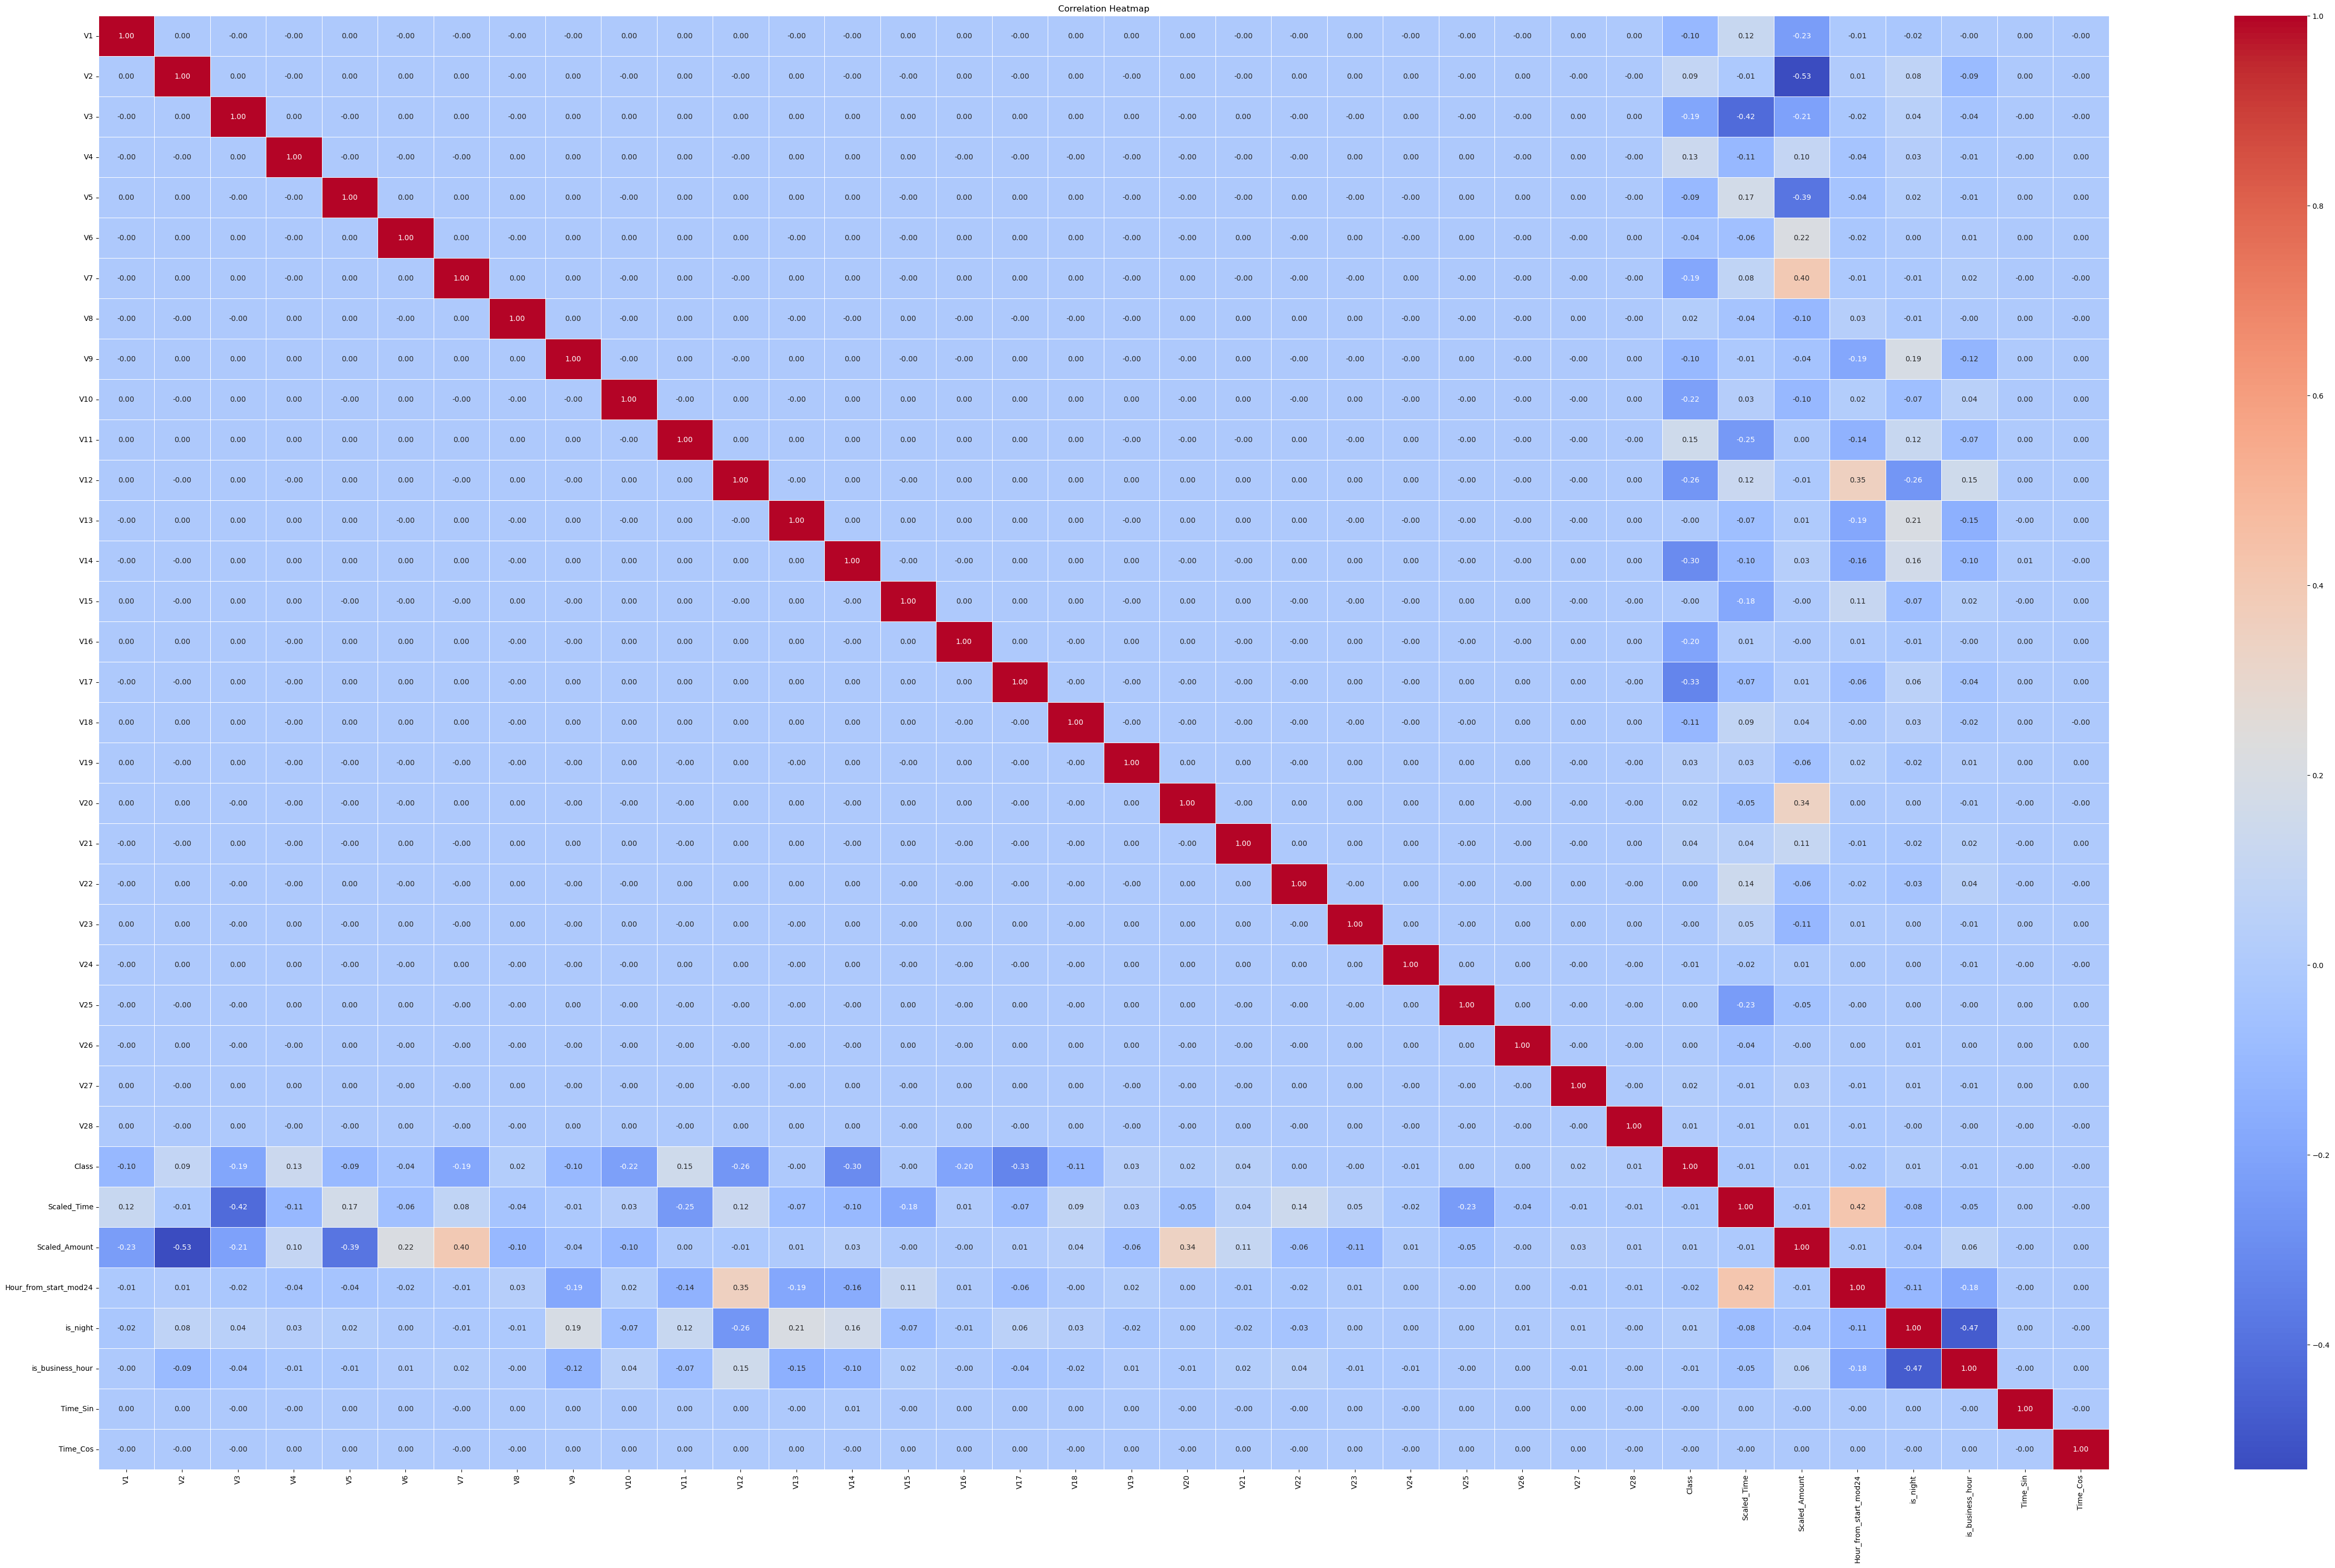

In [41]:
corr = df.corr()
plt.figure(figsize=(50,30))
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt="0.2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 10. CORRELATION OF FEATURES BASED ON CLASS

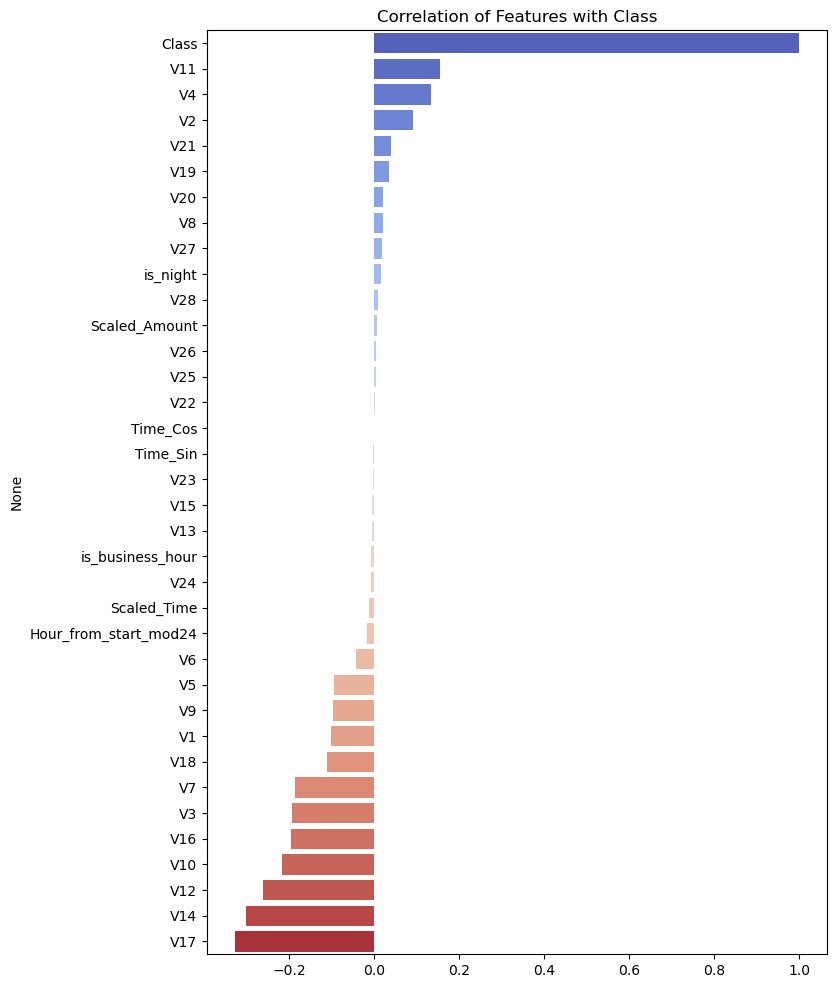

In [42]:
class_corr = df.corr()["Class"].sort_values(ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(
    x=class_corr.values,        # 1D array of correlation values
    y=class_corr.index,         # feature names
    hue=class_corr.index,       # assign y variable to hue
    palette="coolwarm",
    legend=False
)

plt.title("Correlation of Features with Class")
plt.show()

# 11. Weaker Correlations

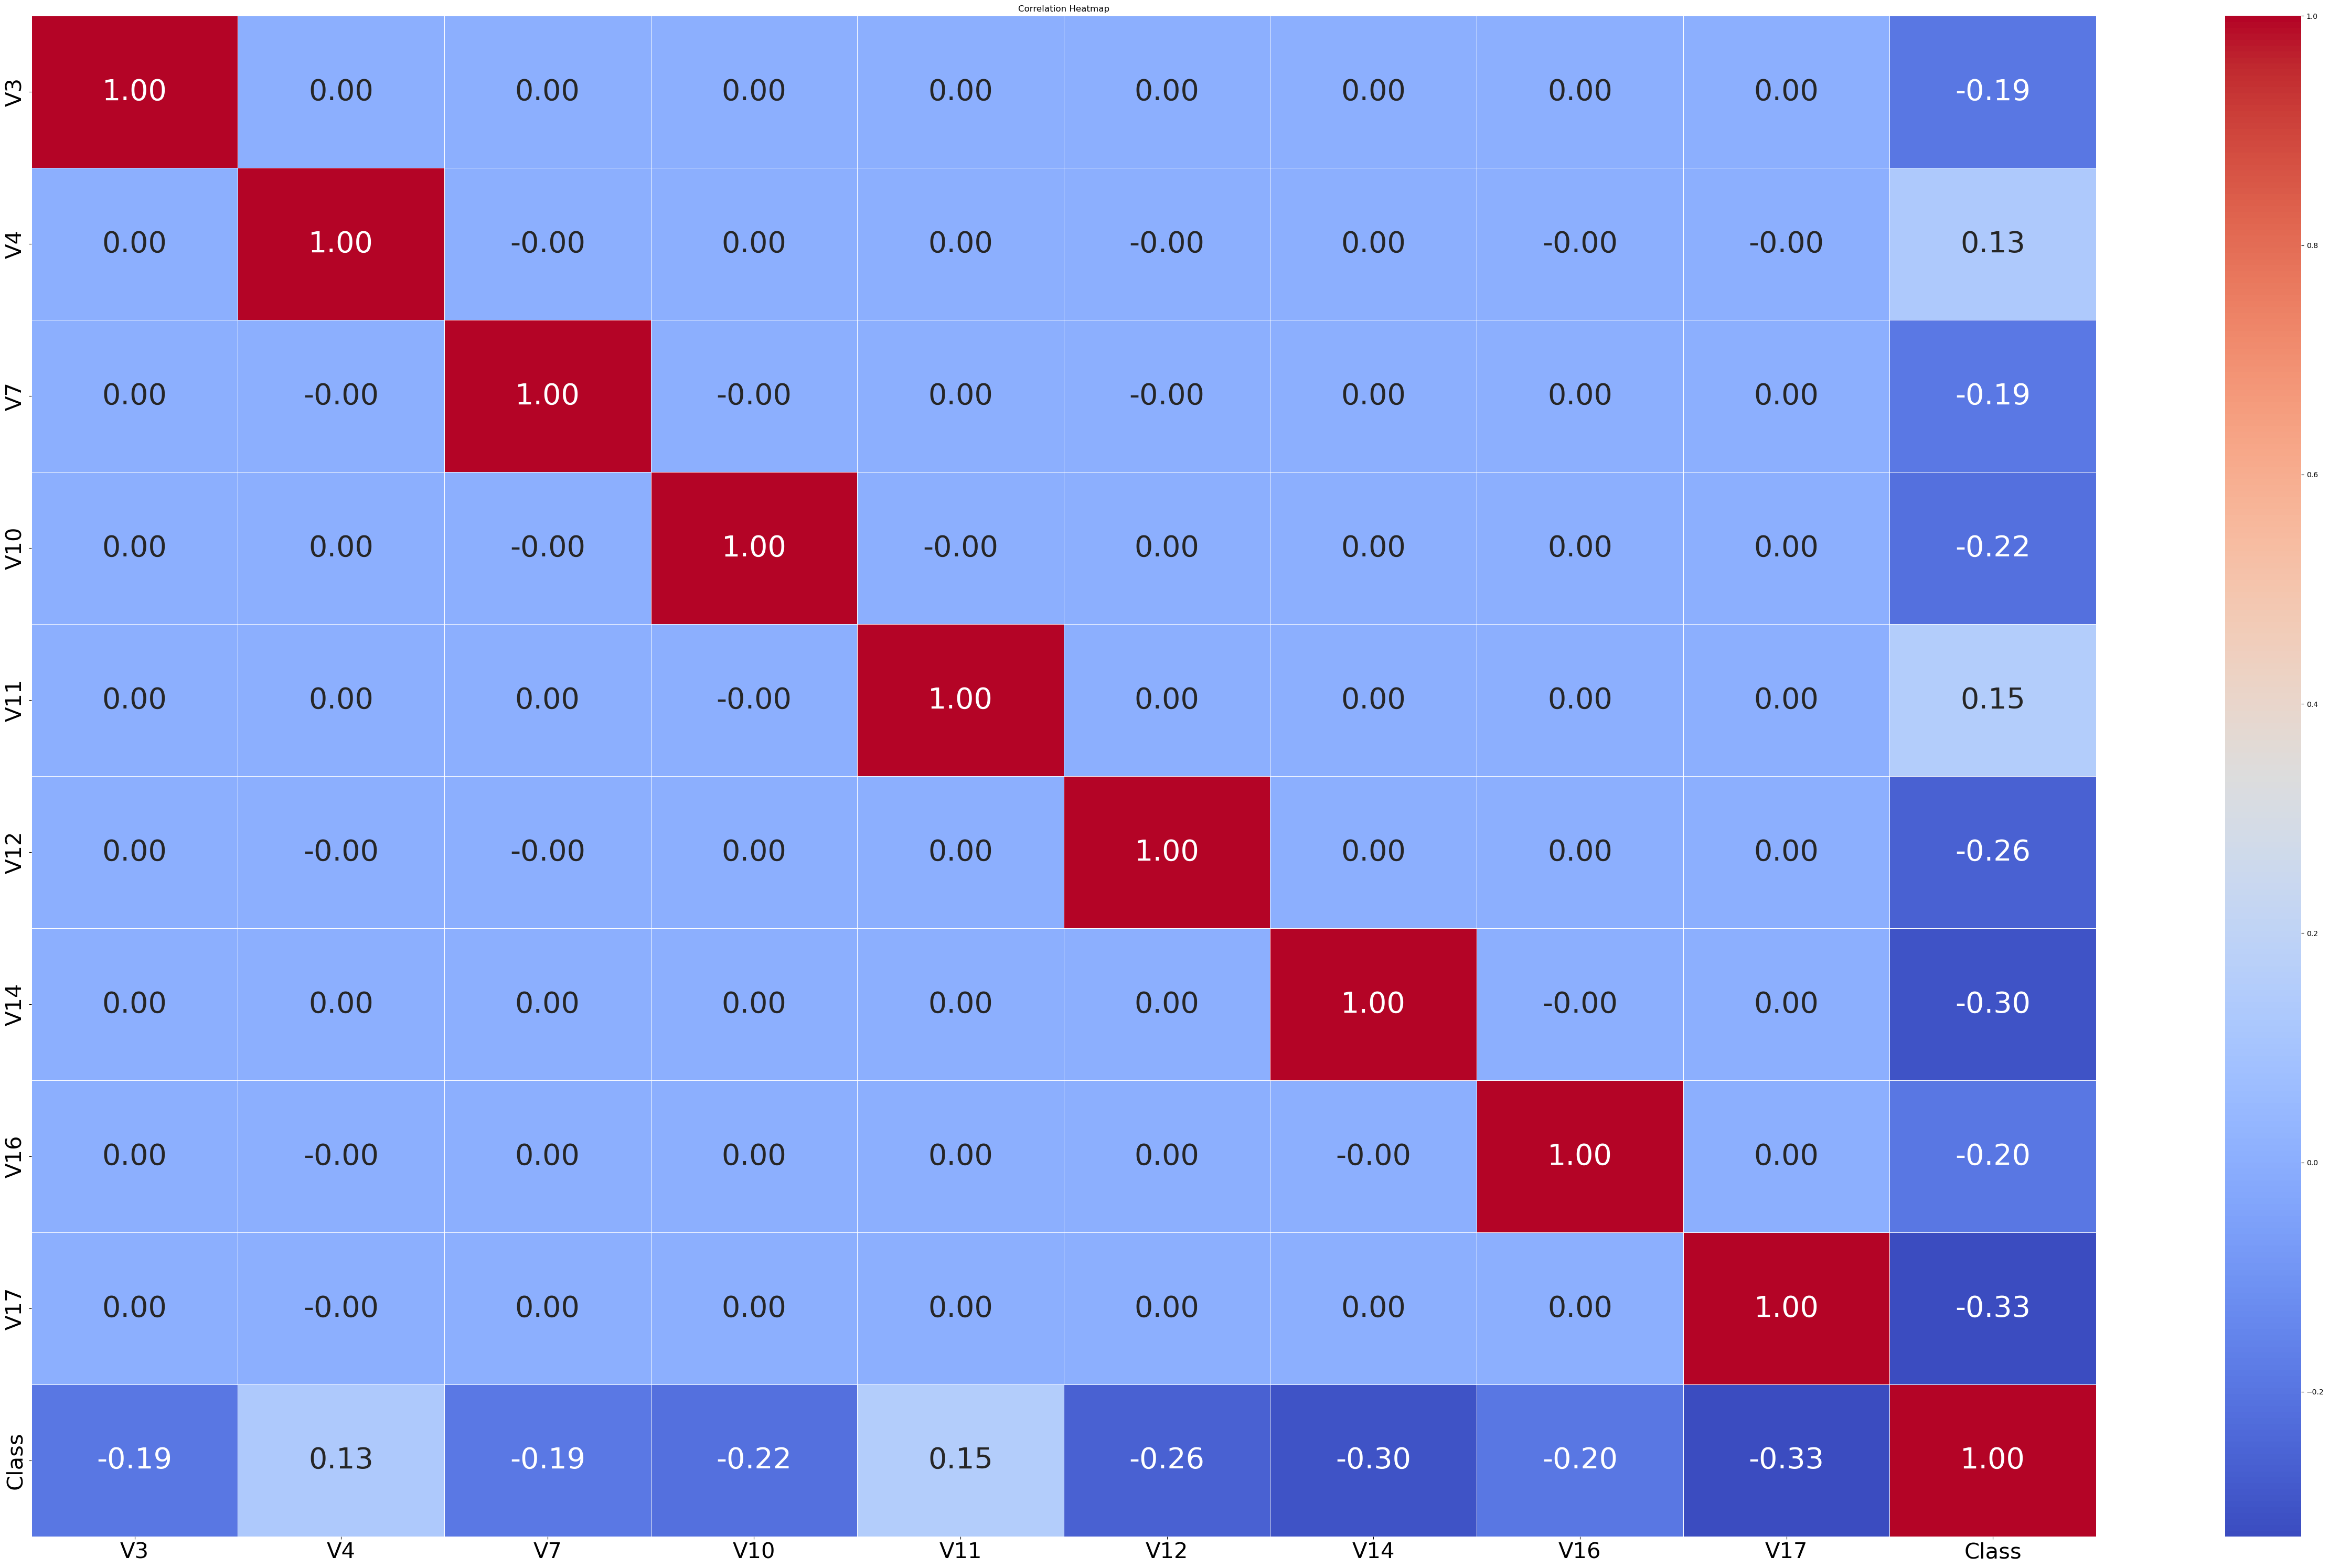

In [43]:
df_copy = df.copy()

# Drop columns with weak correlation to "Class"
class_corr = df_copy.corr()["Class"]
for column, corr_val in class_corr.items():
    if abs(corr_val) < 0.13:
        df_copy.drop(columns=column, inplace=True)

# Recompute correlation matrix after dropping
corr = df_copy.corr()

# Plot heatmap
plt.figure(figsize=(50,30))
plt.xticks(fontsize=30) 
plt.yticks(fontsize=30)
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt=".2f", annot_kws={"size": 40})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 12. Stronger Correlations

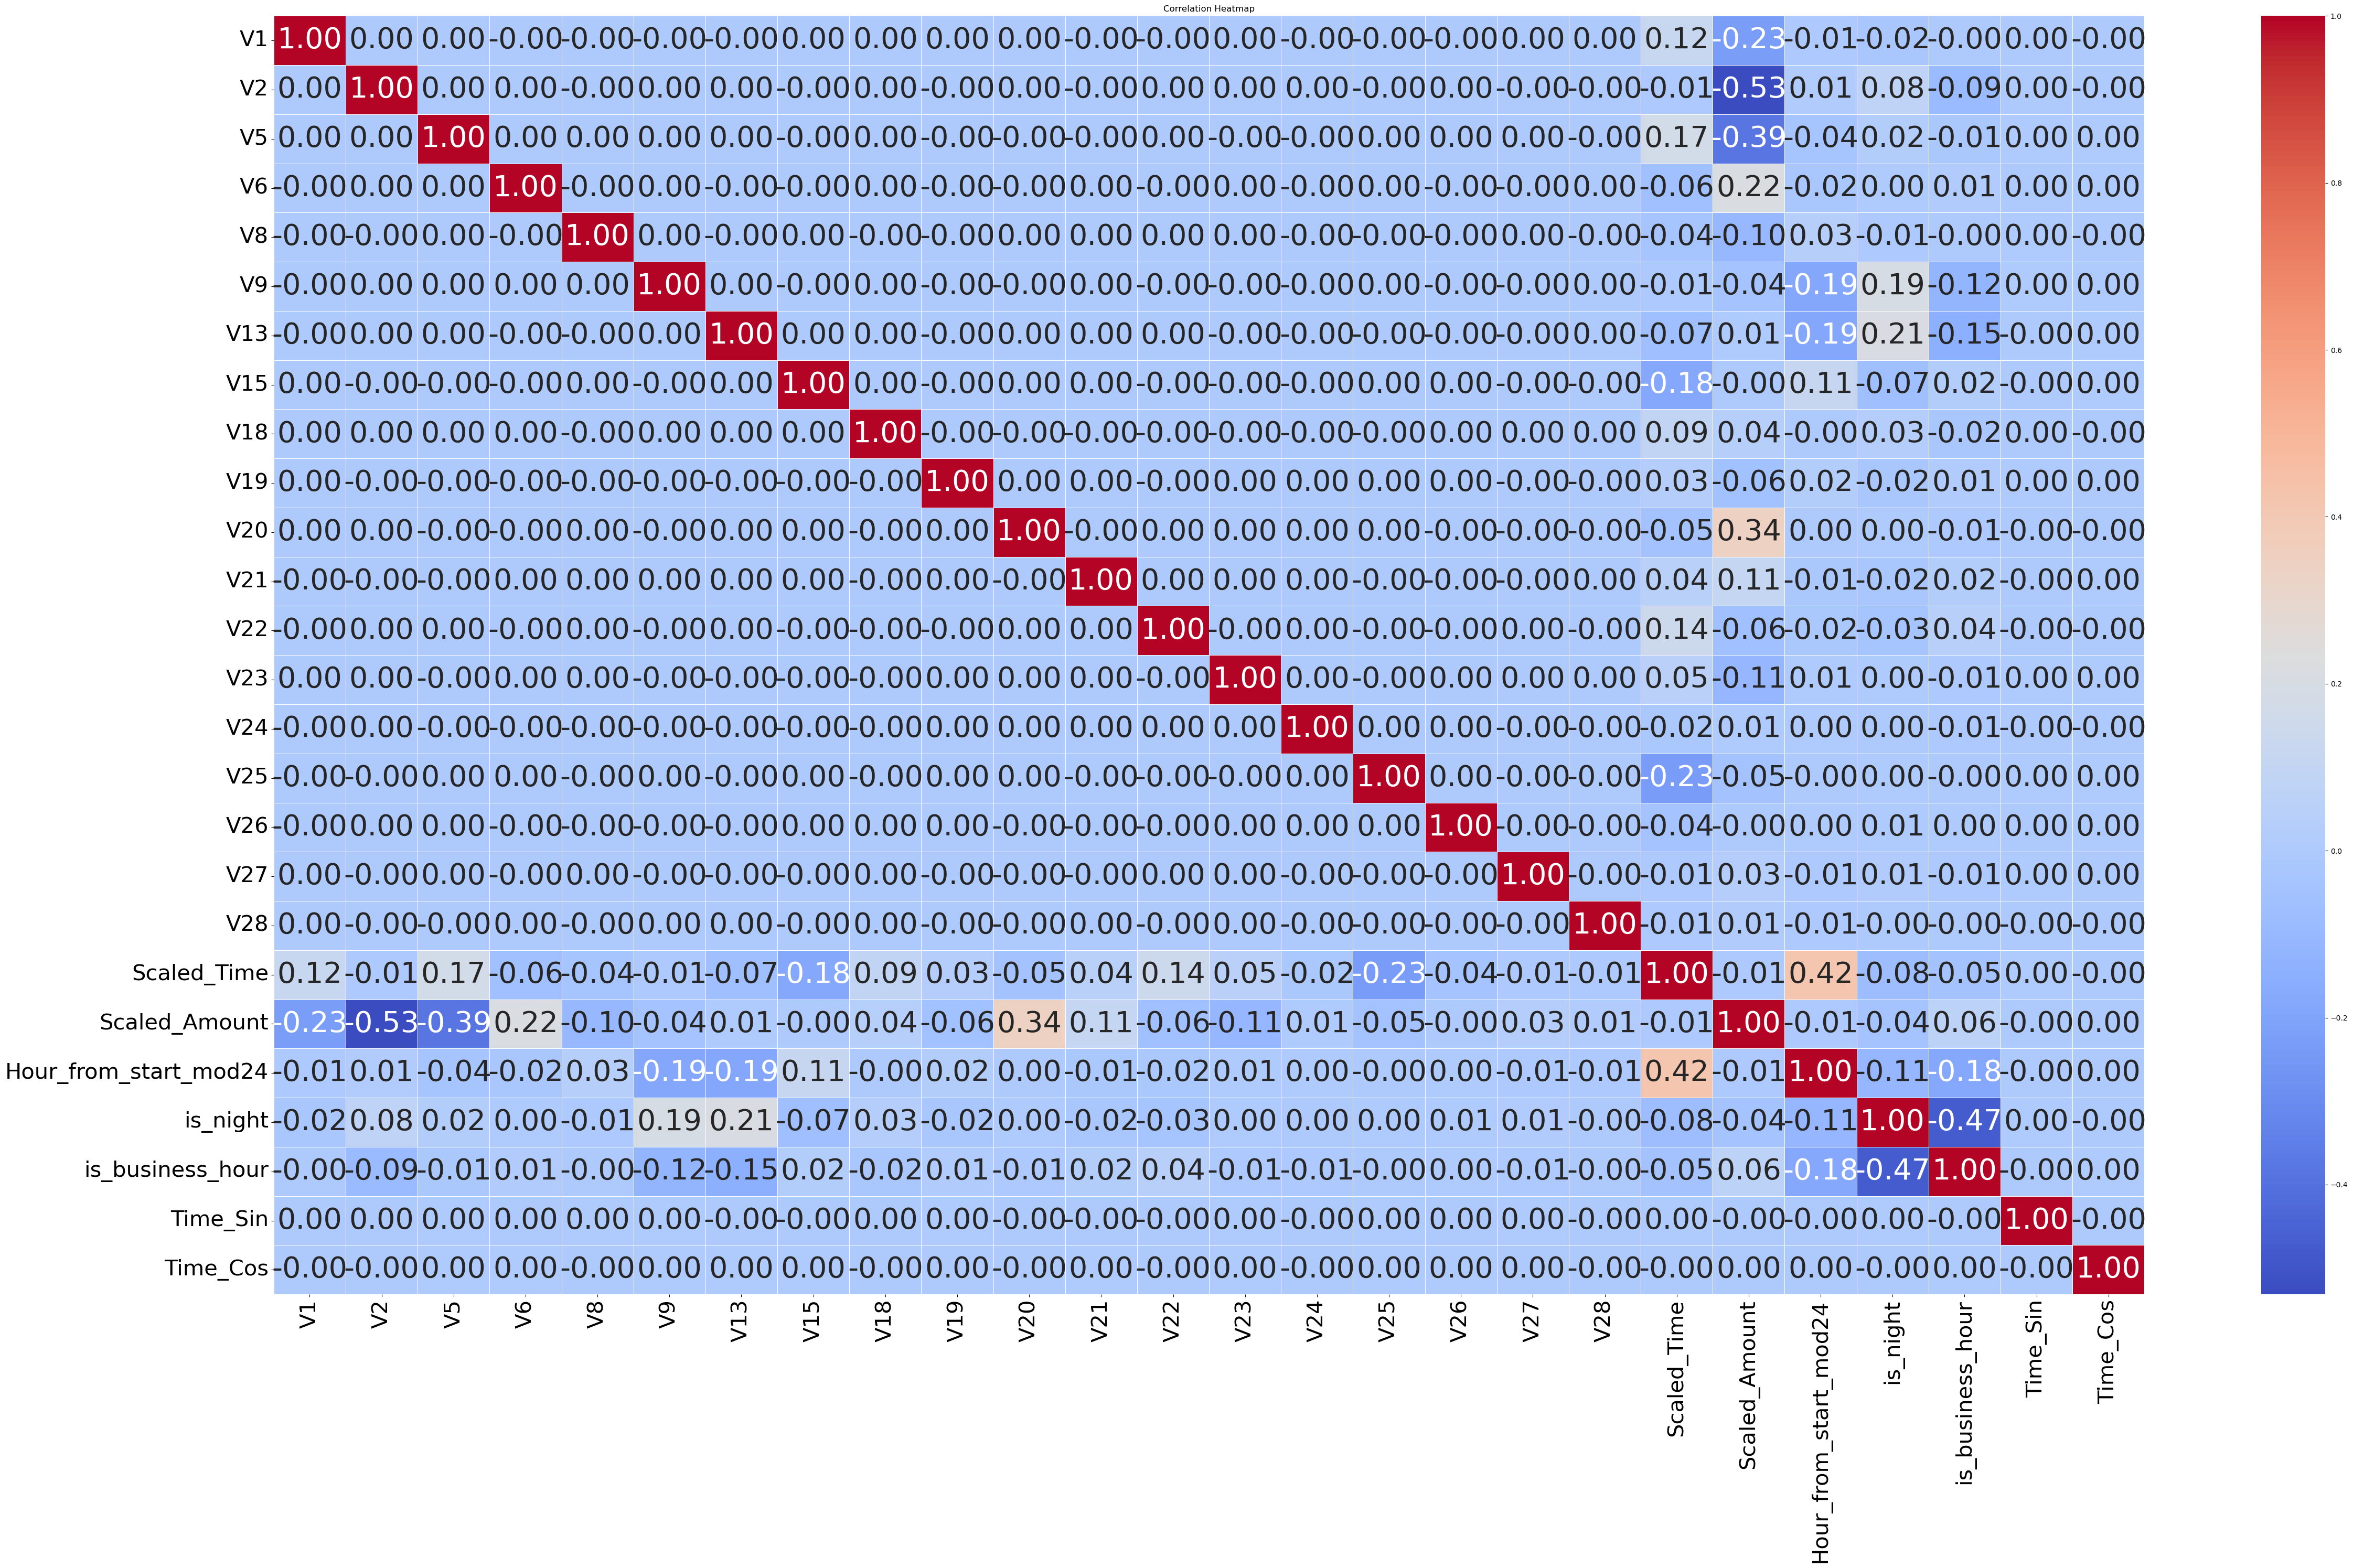

In [44]:
df_copy = df.copy()

# Drop columns with weak correlation to "Class"
class_corr = df_copy.corr()["Class"]
for column, corr_val in class_corr.items():
    if abs(corr_val) > 0.13:
        df_copy.drop(columns=column, inplace=True)

# Recompute correlation matrix after dropping
corr = df_copy.corr()

# Plot heatmap
plt.figure(figsize=(50,30))
plt.xticks(fontsize=30) 
plt.yticks(fontsize=30)
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, fmt=".2f", annot_kws={"size": 40})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
# splitting the data to apply different techniques of handling imbalance data on training set.
X = df.drop(columns = ['Class']).astype("float32")
y = df['Class']

""" 
Please note that I'm having conflict with using imblearn and my installed libraries. So I'll separate both libraries.
To solve this, we'll import first the X and y features to a separate CSV file so I can access the datasets then use library in a separate kernel.
"""

# X.to_csv("X_creditcard.csv")
# y.to_csv("y_creditcard.csv")

# PLEASE CHECK THE 2ND PART OF THIS TOPIC.